## Imports

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
    classification_report
)

# Fixing the seed makes random results reproducible across runs.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## Create Sample Dataset

In [29]:
n_train = 500

# Create synthetic training features with realistic ranges.
train_df = pd.DataFrame({
    "study_hours": np.clip(np.random.normal(5, 2, n_train), 0, 12),
    "sleep_hours": np.clip(np.random.normal(7, 1.2, n_train), 3, 11),
    "attendance": np.clip(np.random.normal(75, 15, n_train), 0, 100),
    "previous_score": np.clip(np.random.normal(65, 12, n_train), 0, 100)
})

# Build a hidden scoring formula, then convert it to pass/fail labels.
train_score = (
    0.9 * train_df["study_hours"]
    + 0.06 * train_df["attendance"]
    + 0.08 * train_df["previous_score"]
    + 0.5 * train_df["sleep_hours"]
    + np.random.normal(0, 3, n_train)
)

# Thresholding turns a continuous score into binary classes (0/1).
train_df["passed"] = (train_score > 16).astype(int)

# Quick preview of generated data.
train_df.head()

,study_hours,sleep_hours,attendance,previous_score,passed
0,5.993428,8.111413,95.990332,74.340333,1
1,4.723471,9.291300,88.869505,58.385771,1
2,6.295377,5.321719,75.894456,55.181613,0
3,8.046060,7.675563,65.295948,64.959507,1
4,4.531693,6.219229,85.473350,62.957785,0


## 1. Quick EDA: What does the dataset look like?

Before building a model, we first inspect the dataset to understand:
- how many rows and columns we have
- what each column looks like
- whether the target variable is present
- whether any values are missing

This helps us avoid blindly fitting a model without understanding the data first.

In [30]:
# Show the first few rows of the dataset
# This gives us a quick sense of what each column contains.
train_df.head()

,study_hours,sleep_hours,attendance,previous_score,passed
0,5.993428,8.111413,95.990332,74.340333,1
1,4.723471,9.291300,88.869505,58.385771,1
2,6.295377,5.321719,75.894456,55.181613,0
3,8.046060,7.675563,65.295948,64.959507,1
4,4.531693,6.219229,85.473350,62.957785,0


In [31]:
# Check the shape of the dataset
# rows = number of observations/examples
# columns = number of features/variables
print("Rows and columns:", train_df.shape)

# Check the column names and data types
# This helps identify numeric, categorical, and text-based variables.
train_df.info()

Rows and columns: (500, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   study_hours     500 non-null    float64
 1   sleep_hours     500 non-null    float64
 2   attendance      500 non-null    float64
 3   previous_score  500 non-null    float64
 4   passed          500 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 19.7 KB


## 2. Check missing values and basic patterns

Missing values can affect model training because many machine learning models cannot directly handle empty values.

Here, we check which columns have missing data and how much is missing. This helps us decide whether to remove, fill, or ignore missing values later in preprocessing.

In [32]:
# Count missing values in each column
missing_values = train_df.isnull().sum()

# Show only columns that actually have missing values
missing_values = missing_values[missing_values > 0]

print("Columns with missing values:")
print(missing_values)

Columns with missing values:
Series([], dtype: int64)


In [33]:
# Get summary statistics for numeric columns
# This helps us understand the scale, spread, and possible outliers in the data.
train_df.describe()

,study_hours,sleep_hours,attendance,previous_score,passed
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,5.015709,7.038191,76.239236,65.386315,0.698000
std,1.947191,1.173597,14.413563,11.772142,0.459585
min,0.000000,3.763736,31.556169,29.715336,0.000000
25%,3.599385,6.285650,65.963556,57.656766,0.000000
50%,5.025594,7.034238,76.797088,64.893040,1.000000
75%,6.273567,7.781491,86.321075,73.397233,1.000000
max,12.000000,10.158858,100.000000,100.000000,1.000000


## 3. Explore the target variable

Since this is a supervised learning task, the target variable is what the model is trying to predict.

Before training, we should check whether the target classes are balanced or imbalanced.  
If one class appears much more often than another, accuracy alone may be misleading.

In [34]:
# Replace 'target' with the actual name of the column we are trying to predict
target_column = "passed"

# Count how many examples belong to each class
train_df[target_column].value_counts()

,count
passed,
1,349
0,151


<Axes: title={'center': 'Target Variable Distribution'}, xlabel='passed'>

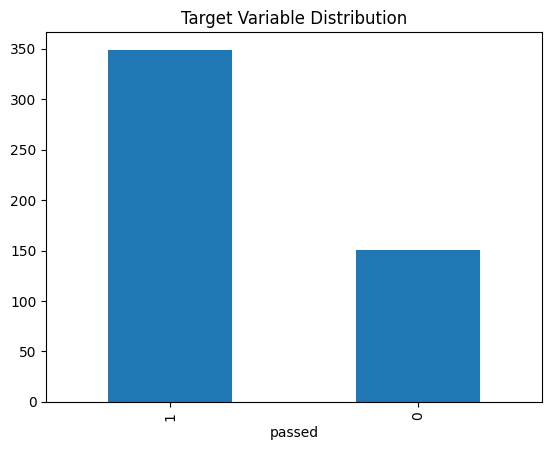

In [35]:
# Visualise the target distribution
# This makes it easier to see whether the classes are balanced.
train_df[target_column].value_counts().plot(
    kind="bar",
    title="Target Variable Distribution"
)

# A Birds-Eye View: Features, Targets and Predictions

### Set-up of a basic supervised model

In [36]:
feature_cols = ["study_hours", "sleep_hours", "attendance", "previous_score"]
target_col = "passed"

X = train_df[feature_cols]
y = train_df[target_col]

# Shapes tell us how many rows/examples and columns/features we have.
print("X shape:", X.shape)
print("y shape:", y.shape)

# Class counts help us see imbalance (more 1s than 0s, or vice versa).
print("\nTarget distribution:")
print(y.value_counts())

X shape: (500, 4)
y shape: (500,)

Target distribution:
passed
1    349
0    151
Name: count, dtype: int64


The dataset has `500` rows.

Each row represents one student, and each column gives information about that student.

There are 4 feature columns (inputs):

- `study_hours`
- `sleep_hours`
- `attendance`
- `previous_score`

The target column (output) is:

- `passed`

In supervised learning, we train a model to map **features -> target**.
So here, the model learns patterns in the four feature columns to predict whether `passed` is `0` or `1`.

## Understanding the Target

The target is `passed`, so this is a **binary classification** problem:

- `0` = did not pass
- `1` = passed

Why this matters:

- In classification, the model predicts a class label, not a continuous number.
- Before training, we check class balance because highly imbalanced data can make accuracy look better than it really is.

How to interpret this notebook's output:

- The normalized class output is about `1: 0.698` and `0: 0.302`.
- That means around 70% of students are in class `1`.
- So a naive model that always predicts `1` can already get about 70% accuracy.

In [37]:
# Normalized counts = percentages for each class.
# Example: 0.68 means 68% of students are in that class.
y.value_counts(normalize=True)

,proportion
passed,
1,0.698
0,0.302


## Visualising the Problem

Before training models, we can quickly visualise two features.

This is not full EDA. The goal is just to build intuition about whether there might be a pattern a model can learn.

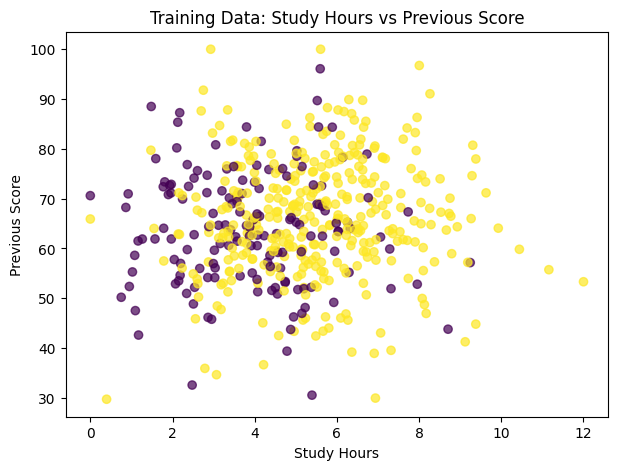

In [38]:
plt.figure(figsize=(7, 5))

# Each dot is one student; color shows pass/fail class.
plt.scatter(
    train_df["study_hours"],
    train_df["previous_score"],
    c=train_df["passed"],
    alpha=0.7
)

plt.xlabel("Study Hours")
plt.ylabel("Previous Score")
plt.title("Training Data: Study Hours vs Previous Score")
plt.show()

## Create a Labelled Test Dataset

The training dataset is used to teach the model.

The test dataset contains new examples used to evaluate the model.

In real Kaggle competitions, test labels are usually hidden. In this learning notebook, we include labels so we can practise evaluation.

In [39]:
n_test = 100

# Build a separate held-out dataset for evaluation.
test_df = pd.DataFrame({
    "study_hours": np.clip(np.random.normal(5, 2, n_test), 0, 12),
    "sleep_hours": np.clip(np.random.normal(7, 1.2, n_test), 3, 11),
    "attendance": np.clip(np.random.normal(75, 15, n_test), 0, 100),
    "previous_score": np.clip(np.random.normal(65, 12, n_test), 0, 100)
})

# Use the same hidden formula style to generate labels for test data.
test_score = (
    0.9 * test_df["study_hours"]
    + 0.06 * test_df["attendance"]
    + 0.08 * test_df["previous_score"]
    + 0.5 * test_df["sleep_hours"]
    + np.random.normal(0, 3, n_test)
)

# Keep target creation identical between train/test for fair evaluation.
test_df["passed"] = (test_score > 16).astype(int)

# Reuse the same feature/target column definitions.
X_test = test_df[feature_cols]
y_test = test_df[target_col]

test_df.head()

,study_hours,sleep_hours,attendance,previous_score,passed
0,6.141226,4.748137,80.802128,67.206014,1
1,6.936369,7.743654,91.364706,97.316404,1
2,4.337383,6.237565,100.000000,69.197600,1
3,3.775527,5.572400,90.355643,52.951345,1
4,2.829699,6.250786,78.739629,63.854429,0


## Baseline Model

A **baseline** is the minimum performance level your real models should beat.

Here we use `DummyClassifier(strategy="most_frequent")`, which always predicts the majority class.

How to interpret this notebook's output:

- Baseline accuracy is about **`0.70`**.
- This means if we always guess "passed", we are correct about 70% of the time.
- So if another model scores only around 0.70, it is not adding much practical value.

In [40]:
# DummyClassifier gives a simple reference point.
baseline_model = DummyClassifier(strategy="most_frequent")

# Even baseline follows the same fit/predict pattern as other models.
baseline_model.fit(X, y)

baseline_preds = baseline_model.predict(X_test)
baseline_accuracy = accuracy_score(y_test, baseline_preds)

# This is the score to beat. Real models should do better than baseline.
print("Baseline accuracy:", baseline_accuracy)

Baseline accuracy: 0.7


## Model 1: Logistic Regression

Logistic regression is a common first model for binary classification.

Conceptually:

- It estimates `P(passed = 1 | features)`.
- If the probability is above a threshold (usually 0.5), it predicts class `1`.

Why scaling is used:

- Features are on different scales (`study_hours` vs `attendance`), and logistic regression is sensitive to scale.
- `StandardScaler` helps training behave more consistently.

How to interpret this notebook's output:

- Logistic regression accuracy is about **`0.74`**.
- This beats the baseline (`0.70`), so the model is learning useful signal from the features.
- The `probability_passed` column helps identify confidence: values near 0.5 are less certain predictions.

In [41]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Fit on training data only.
logistic_model.fit(X, y)

logistic_preds = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_preds)

# Compare this accuracy against baseline accuracy from earlier.
print("Logistic Regression accuracy:", logistic_accuracy)

# Build a small table to inspect predictions vs true labels.
prediction_table = X_test.copy()
prediction_table["actual"] = y_test
prediction_table["predicted"] = logistic_preds
prediction_table["probability_passed"] = logistic_model.predict_proba(X_test)[:, 1]

# If probability is near 0.5, the model is less confident.
prediction_table.head(10)

Logistic Regression accuracy: 0.74


,study_hours,sleep_hours,attendance,previous_score,actual,predicted,probability_passed
0,6.141226,4.748137,80.802128,67.206014,1,1,0.789511
1,6.936369,7.743654,91.364706,97.316404,1,1,0.967133
2,4.337383,6.237565,100.000000,69.197600,1,1,0.786365
3,3.775527,5.572400,90.355643,52.951345,1,1,0.556601
4,2.829699,6.250786,78.739629,63.854429,0,0,0.426769
5,3.349179,6.778570,90.676327,43.685044,1,1,0.530231
6,10.898189,6.274306,77.173317,64.032803,1,1,0.985117
7,7.489359,4.353321,75.358546,55.003327,0,1,0.830378
8,2.297851,8.076479,69.728786,75.984683,0,0,0.449645
9,2.355084,8.529850,98.451200,58.405517,1,1,0.623141


## Model 2: Decision Tree

A decision tree makes predictions by chaining simple yes/no rules.

For example, it may split on questions like:

- Is `previous_score` above a threshold?
- Is `attendance` above a threshold?
- Is `study_hours` above a threshold?

Why beginners like trees:

- They are visual and easy to explain.
- But they can overfit if allowed to grow too deep.

How to interpret this notebook's output:

- Shallow tree (`max_depth=3`) accuracy is about **`0.73`**.
- It beats baseline, but is slightly below logistic regression (`0.74`) and random forest (`0.75`).

In [42]:
# Restrict depth to keep the tree interpretable and reduce overfitting risk.
tree_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

tree_model.fit(X, y)

tree_preds = tree_model.predict(X_test)
tree_accuracy = accuracy_score(y_test, tree_preds)

# Useful to compare this with logistic regression and baseline.
print("Decision Tree accuracy:", tree_accuracy)

Decision Tree accuracy: 0.73


## Visualise the Decision Tree

One advantage of decision trees is that we can inspect the rules they learned.

Each node asks a question.

Each branch follows an answer.

Each leaf gives a prediction.

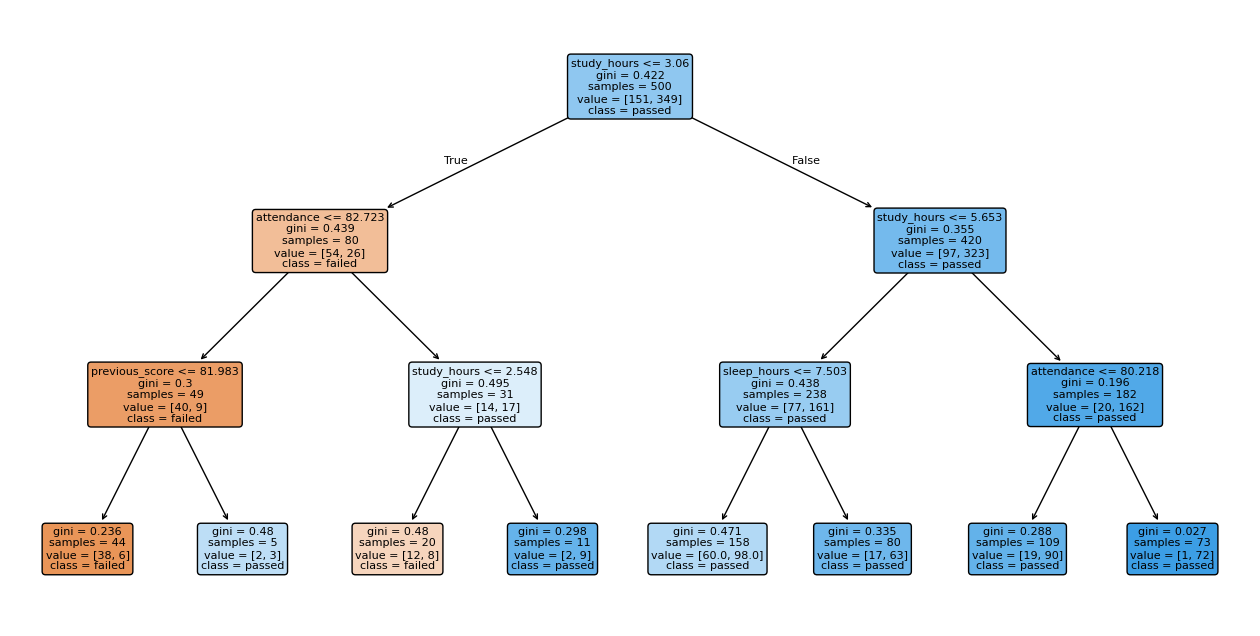

In [43]:
# Larger figure helps us read split rules clearly.
plt.figure(figsize=(16, 8))

plot_tree(
    tree_model,
    feature_names=feature_cols,
    class_names=["failed", "passed"],
    filled=True,
    rounded=True
)

# In each node: gini = impurity, samples = rows, value = class counts.
plt.show()

## Overfitting Demo

**Overfitting** means the model memorizes training data patterns (including noise) but generalizes poorly to unseen data.

How to detect it:

- Compare training vs test accuracy.
- A large gap is a warning sign.

How to interpret this notebook's output:

- Deep tree training accuracy is about **`1.00`**.
- Deep tree test accuracy is about **`0.72`**.
- This gap (`1.00` vs `0.72`) is a classic overfitting example.

In [44]:
deep_tree_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=RANDOM_STATE
)

deep_tree_model.fit(X, y)

deep_tree_train_preds = deep_tree_model.predict(X)
deep_tree_test_preds = deep_tree_model.predict(X_test)

deep_tree_train_accuracy = accuracy_score(y, deep_tree_train_preds)
deep_tree_test_accuracy = accuracy_score(y_test, deep_tree_test_preds)

# Big gap (train >> test) usually indicates overfitting.
print("Deep Tree training accuracy:", deep_tree_train_accuracy)
print("Deep Tree test accuracy:", deep_tree_test_accuracy)

Deep Tree training accuracy: 1.0
Deep Tree test accuracy: 0.72


## Model 3: Random Forest

A random forest combines many decision trees and aggregates their votes.

Why it often works well:

- Each tree sees a slightly different view of the data.
- Averaging across trees reduces variance and usually improves generalization.

How to interpret this notebook's output:

- Random forest accuracy is about **`0.75`**.
- This is one of the best scores in this notebook and better than baseline/logistic/tree in this run.

In [45]:
forest_model = RandomForestClassifier(
    n_estimators=200,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

forest_model.fit(X, y)

forest_preds = forest_model.predict(X_test)
forest_accuracy = accuracy_score(y_test, forest_preds)

# Random forests are often strong on tabular data.
print("Random Forest accuracy:", forest_accuracy)

Random Forest accuracy: 0.75


## Feature Importance

Random forests can estimate which features were most useful.

This helps us understand what the model relied on.

Feature importance is useful, but it does not prove causation.

,feature,importance
0,study_hours,0.453341
2,attendance,0.206989
3,previous_score,0.170021
1,sleep_hours,0.169649


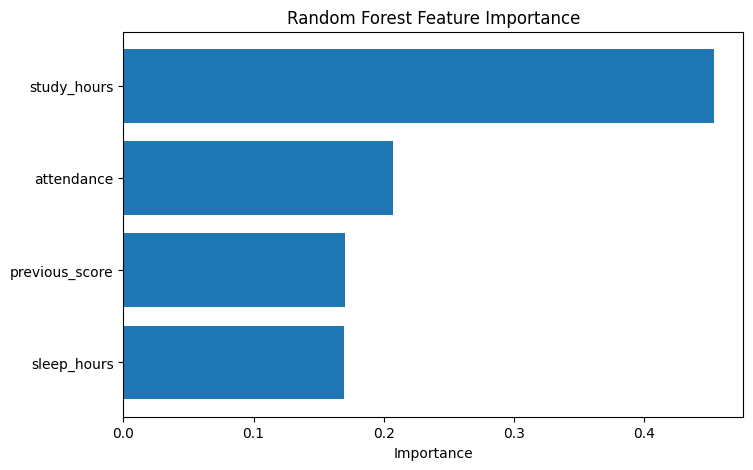

In [46]:
# Convert model importances into a sorted table for easier reading.
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": forest_model.feature_importances_
}).sort_values("importance", ascending=False)

# Top rows indicate the strongest contributors for this model.
display(feature_importance)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.show()

## Model 4: Gradient Boosting (Many Weak Learners)

Gradient boosting is an ensemble method that combines **many weak learners** (usually shallow decision trees).

What is a weak learner?

- A model that performs only slightly better than random guessing by itself.
- In boosting, each weak learner is simple (often a shallow tree/stump), not a highly complex model.

How boosting works:

1. Train the first weak learner.
2. Measure its errors.
3. Train the next weak learner to focus more on the mistakes from earlier learners.
4. Add learner outputs together (with small step sizes) to build a stronger final model.

So the strength comes from the **sequence of many weak learners**, not from one powerful tree.

How to interpret this notebook's output:

- Gradient boosting accuracy is about **`0.72`** in this run.
- This means the weak-learner ensemble is learning useful signal and beating baseline (`0.70`).
- It is still below random forest (`0.75`) here, which is normal because best model choice depends on data and hyperparameters.

In [47]:
boosting_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=2,
    random_state=RANDOM_STATE
)

# Each estimator is a weak learner; boosting combines many of them.
boosting_model.fit(X, y)

boosting_preds = boosting_model.predict(X_test)
boosting_accuracy = accuracy_score(y_test, boosting_preds)

# Keep a note of this value for final ranking.
print("Gradient Boosting accuracy:", boosting_accuracy)

Gradient Boosting accuracy: 0.72


## Compare Models

This table compares model performance using **accuracy**:

- `accuracy = correct predictions / total predictions`

How to interpret this notebook's outputs:

- Baseline is about `0.70`.
- Logistic Regression is about `0.74`.
- Decision Tree is about `0.73`.
- Deep Decision Tree test accuracy is about `0.72` (despite perfect train accuracy, showing overfitting).
- Random Forest is about `0.75` (best among these untuned models).
- Gradient Boosting is about `0.72`.

Main takeaway: several real models beat baseline, and random forest gives the strongest simple result in this run.

In [48]:
# Collect all metrics in one table so comparison is side-by-side.
results = pd.DataFrame({
    "model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Deep Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        tree_accuracy,
        deep_tree_test_accuracy,
        forest_accuracy,
        boosting_accuracy
    ]
})

# Sorted table makes it easy to identify top-performing models.
results.sort_values("accuracy", ascending=False)

,model,accuracy
4,Random Forest,0.75
1,Logistic Regression,0.74
2,Decision Tree,0.73
3,Deep Decision Tree,0.72
5,Gradient Boosting,0.72
0,Baseline,0.70


## Confusion Matrix

Accuracy gives one summary number, but a confusion matrix shows **what kinds of errors** the model makes.

For binary classes (`0` = failed, `1` = passed), the matrix layout is:

- Top-left: true `0` predicted as `0` (correct)
- Top-right: true `0` predicted as `1` (false positive)
- Bottom-left: true `1` predicted as `0` (false negative)
- Bottom-right: true `1` predicted as `1` (correct)

How to interpret this notebook's random-forest matrix (approximately `[[10, 20], [5, 65]]`):

- Correct: `10 + 65 = 75`
- Total: `100`
- Accuracy: `75 / 100 = 0.75`

Interpretation: the model is better at identifying class `1` (passed) than class `0` (failed), because it misses many class `0` examples (`20` false positives).

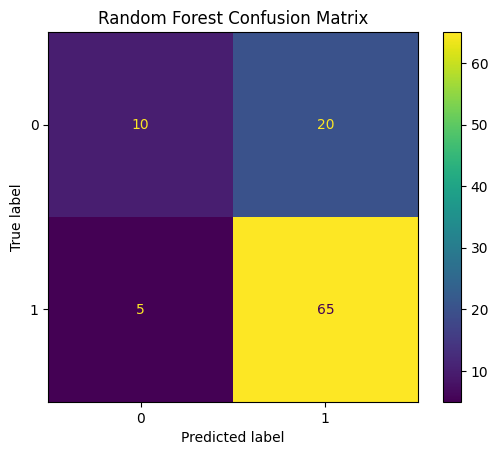

In [49]:
# Diagonal cells are correct predictions; off-diagonal cells are mistakes.
# Read row-wise: each row is the true class, columns are predicted class.
ConfusionMatrixDisplay.from_predictions(y_test, forest_preds)
plt.title("Random Forest Confusion Matrix")
plt.show()

## Simple Hyperparameter Tuning

**Hyperparameters** are model settings chosen before training (unlike learned parameters).

For random forests, examples include:

- number of trees (`n_estimators`)
- tree depth (`max_depth`)
- leaf size (`min_samples_leaf`)

`GridSearchCV` tests combinations and selects the best by cross-validation score.

How to interpret this notebook's output:

- Best parameters are about `{'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}`.
- Best CV score is about `0.748`.
- Tuned test accuracy is about `0.73`.

Important learning point: a model can score well in CV but still not beat another model on final test data (here, untuned random forest at `0.75` was still higher).

In [50]:
# Candidate settings we want GridSearchCV to try.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, None],
    "min_samples_leaf": [1, 5]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

# GridSearchCV trains multiple models and keeps the best one.
grid_search.fit(X, y)

# best_estimator_ is a fully trained model with the best hyperparameters.
tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)
tuned_accuracy = accuracy_score(y_test, tuned_preds)

# best_score_ is CV performance on training folds; tuned_accuracy is final test performance.
print("Best parameters:", grid_search.best_params_)
print("Best grid search score:", grid_search.best_score_)
print("Tuned Random Forest test accuracy:", tuned_accuracy)

Best parameters: {'max_depth': 3, 'min_samples_leaf': 5, 'n_estimators': 200}
Best grid search score: 0.747997979943727
Tuned Random Forest test accuracy: 0.73


## Model 5: Neural Network

A neural network learns layers of patterns.

It can capture complex relationships, but it needs more care than most sklearn models.

For tabular data, random forests and gradient boosting are often strong starting points.

We still include a neural network because it is an important model family to understand.

In [51]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.random.set_seed(RANDOM_STATE)

# Use a clearly named scaler for NN preprocessing.
nn_scaler = StandardScaler()

# Neural nets usually train better on scaled numeric inputs.
X_scaled = nn_scaler.fit_transform(X)
X_test_scaled = nn_scaler.transform(X_test)

# Small feed-forward network for binary classification.
nn_model = keras.Sequential([
    layers.Input(shape=(X_scaled.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

nn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# history stores per-epoch metrics (useful for plotting learning curves later).
history = nn_model.fit(
    X_scaled,
    y,
    epochs=30,
    batch_size=32,
    verbose=1
)

# Convert probabilities into class labels (0/1).
nn_probs = nn_model.predict(X_test_scaled).ravel()
nn_preds = (nn_probs >= 0.5).astype(int)

nn_accuracy = accuracy_score(y_test, nn_preds)

# This output helps compare NN performance with tree-based models.
print("Neural Network accuracy:", nn_accuracy)

Epoch 1/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3140 - loss: 0.8156
Epoch 2/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3140 - loss: 0.7645 
Epoch 3/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3840 - loss: 0.7294 
Epoch 4/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4760 - loss: 0.7052 
Epoch 5/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5460 - loss: 0.6881 
Epoch 6/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6200 - loss: 0.6751 
Epoch 7/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6680 - loss: 0.6641 
Epoch 8/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6820 - loss: 0.6536 
Epoch 9/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6840 - loss: 0.6430 
Epoch 10/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7040 - loss: 0.6319 
Epoch 11/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7260 - loss: 0.6203 
Epoch 12/30
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0

## Final Model Comparison

This final table includes all major models, including tuned random forest and neural network.

How to use it:

- Rank models by accuracy.
- Check whether gains are meaningful (not just tiny differences).
- Prefer models that balance performance and interpretability for your goal.

For this seeded run, random forest remains among the top performers (around `0.75`), while tuned random forest is around `0.73`.

Main beginner takeaway: there is no single model that always wins; compare multiple families and validate with held-out data.

In [52]:
final_results = pd.DataFrame({
    "model": [
        "Baseline",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest",
        "Neural Network"
    ],
    "accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        tree_accuracy,
        forest_accuracy,
        boosting_accuracy,
        tuned_accuracy,
        nn_accuracy
    ]
})

# Final leaderboard for this notebook.
final_results.sort_values("accuracy", ascending=False)

,model,accuracy
3,Random Forest,0.75
6,Neural Network,0.75
1,Logistic Regression,0.74
5,Tuned Random Forest,0.73
2,Decision Tree,0.73
4,Gradient Boosting,0.72
0,Baseline,0.70


## Prediction File Demo

A Kaggle submission file usually contains:

- an ID column (to identify each row)
- a prediction column (the model output)

The exact column names and file format depend on each competition's instructions.

Even with a strong model, submission can fail if the file schema is incorrect, so always check the competition's required template.

In [53]:
# Choose the model we want to submit.
final_model = tuned_model

# Predict on test features, then package into submission format.
final_preds = final_model.predict(X_test)

submission = pd.DataFrame({
    "ID": range(len(test_df)),
    "passed": final_preds
})

# Preview to verify column names/order before saving.
submission.head()

,ID,passed
0,0,1
1,1,1
2,2,1
3,3,1
4,4,0


In [54]:
submission.to_csv("submission.csv", index=False)

# If this prints successfully, the submission file is ready to upload.
print("Saved submission.csv")

Saved submission.csv
